Load clean data

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

biometric_df   = pd.read_csv("../data/processed/biometric_clean.csv")
demographic_df = pd.read_csv("../data/processed/demographic_clean.csv")
enrolment_df   = pd.read_csv("../data/processed/enrolment_clean.csv")

## Understand Time & Location Columns

In [19]:
print("Biometric columns:", biometric_df.columns.tolist())
print("Demographic columns:", demographic_df.columns.tolist())
print("Enrolment columns:", enrolment_df.columns.tolist())

Biometric columns: ['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
Demographic columns: ['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
Enrolment columns: ['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17', 'age_18_greater']


In [20]:
# Check data types and convert date column
print(biometric_df.dtypes)
biometric_df['date'] = pd.to_datetime(biometric_df['date'], format='%d-%m-%Y')
demographic_df['date'] = pd.to_datetime(demographic_df['date'], format='%d-%m-%Y')
enrolment_df['date'] = pd.to_datetime(enrolment_df['date'], format='%d-%m-%Y')

# Extract year and month for analysis
biometric_df['year'] = biometric_df['date'].dt.year
biometric_df['month'] = biometric_df['date'].dt.month
demographic_df['year'] = demographic_df['date'].dt.year
enrolment_df['year'] = enrolment_df['date'].dt.year

date            object
state           object
district        object
pincode          int64
bio_age_5_17     int64
bio_age_17_      int64
dtype: object


In [21]:
# Inspect year column
print("Unique years in biometric_df:", sorted(biometric_df['year'].unique()))
print("Year data type:", biometric_df['year'].dtype)
print("\nSample dates:", biometric_df['date'].head())

Unique years in biometric_df: [np.int32(2025)]
Year data type: int32

Sample dates: 0   2025-03-01
1   2025-03-01
2   2025-03-01
3   2025-03-01
4   2025-03-01
Name: date, dtype: datetime64[ns]


## Bivariate Analysis - Enrolments vs Updates

In [22]:
# Calculate total counts by summing age categories
biometric_df['count'] = biometric_df['bio_age_5_17'] + biometric_df['bio_age_17_']
demographic_df['count'] = demographic_df['demo_age_5_17'] + demographic_df['demo_age_17_']
enrolment_df['count'] = enrolment_df['age_0_5'] + enrolment_df['age_5_17'] + enrolment_df['age_18_greater']

# Merge enrolments vs updates
merged = enrolment_df.groupby('state')['count'].sum().to_frame('enrolments')
merged['updates'] = biometric_df.groupby('state')['count'].sum()

merged.dropna(inplace=True)
print(merged.head())

                           enrolments  updates
state                                         
Andaman & Nicobar Islands         491    19988
Andhra Pradesh                 124273  3610776
Arunachal Pradesh                4240    70059
Assam                          225359   945150
Bihar                          593753  4778968


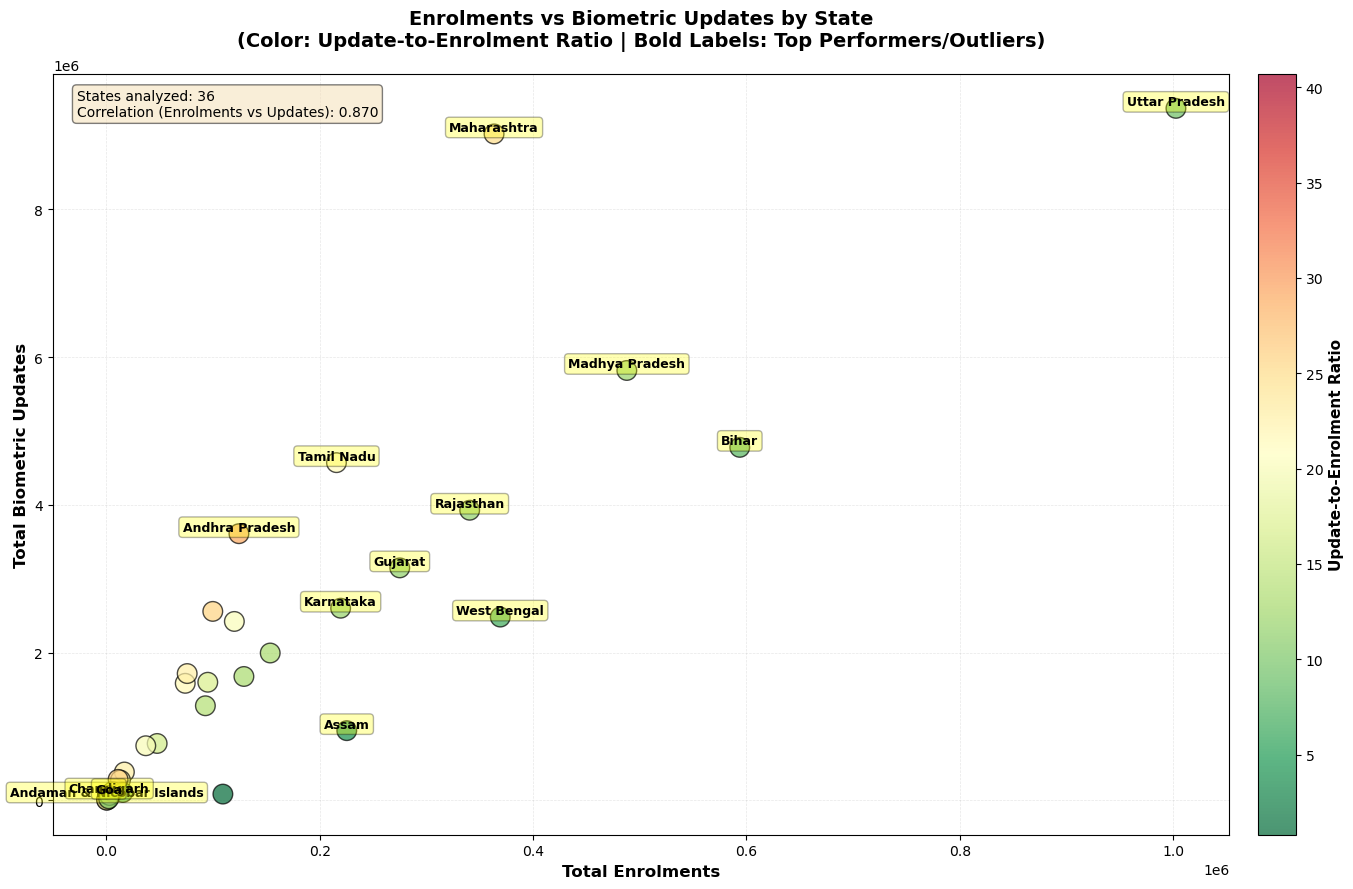

In [23]:
# Create a beautiful scatter plot with enhanced styling
fig, ax = plt.subplots(figsize=(15, 9))

# Ensure ratio exists
if 'update_enrolment_ratio' not in merged.columns:
    merged['update_enrolment_ratio'] = merged['updates'] / merged['enrolments']

# Create scatter plot with size and color based on ratio
colors = merged['update_enrolment_ratio']
scatter = ax.scatter(merged['enrolments'], merged['updates'], 
                     s=200, c=colors, cmap='RdYlGn_r', alpha=0.7, 
                     edgecolors='black', linewidth=1)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Update-to-Enrolment Ratio', fontsize=11, fontweight='bold')

# Add state labels for only top states and outliers to avoid clutter
threshold_enrol = merged['enrolments'].quantile(0.75)
threshold_updates = merged['updates'].quantile(0.75)
high_ratio = merged['update_enrolment_ratio'].quantile(0.90)

for idx in merged.index:
    x, y = merged.loc[idx, 'enrolments'], merged.loc[idx, 'updates']
    ratio = merged.loc[idx, 'update_enrolment_ratio']
    
    # Label if: high updates, high enrolments, or high ratio
    if (x > threshold_enrol or y > threshold_updates or ratio > high_ratio):
        ax.annotate(idx, (x, y), fontsize=9, fontweight='bold', 
                   ha='center', va='bottom', 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_title("Enrolments vs Biometric Updates by State\n(Color: Update-to-Enrolment Ratio | Bold Labels: Top Performers/Outliers)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("Total Enrolments", fontsize=12, fontweight='bold')
ax.set_ylabel("Total Biometric Updates", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Add legend for interpretation
textstr = f'States analyzed: {len(merged)}\nCorrelation (Enrolments vs Updates): {merged["enrolments"].corr(merged["updates"]):.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig("../outputs/figures/enrolments_vs_updates.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Calculate update-to-enrolment ratio
merged['update_enrolment_ratio'] = merged['updates'] / merged['enrolments']

print("Top 5 states with highest update-to-enrolment ratio:")
print(merged.sort_values('update_enrolment_ratio', ascending=False).head(5))

Top 5 states with highest update-to-enrolment ratio:
                           enrolments  updates  update_enrolment_ratio
state                                                                 
Andaman & Nicobar Islands         491    19988               40.708758
Goa                              2280    66554               29.190351
Andhra Pradesh                 124273  3610776               29.055193
Chandigarh                       2620    73552               28.073282
Tripura                         11008   285324               25.919695


### Insight 1: Scale Effect

Larger states exhibit proportionally higher biometric updates, indicating scale-driven service demand.

### Insight 2: Efficiency Spread

States with a higher update-to-enrolment ratio may indicate higher rework, biometric ageing, or enrolment quality challenges, highlighting opportunities for process improvement. Significant variance exists in update-to-enrolment ratios across states, suggesting differences in enrolment quality, population mobility, or biometric ageing.

## Monthly Trends Analysis

In [29]:
# Get top state by total updates
top_state = biometric_df.groupby('state')['count'].sum().nlargest(1).index[0]
print(f"Analyzing monthly trends for: {top_state}")

Analyzing monthly trends for: Uttar Pradesh


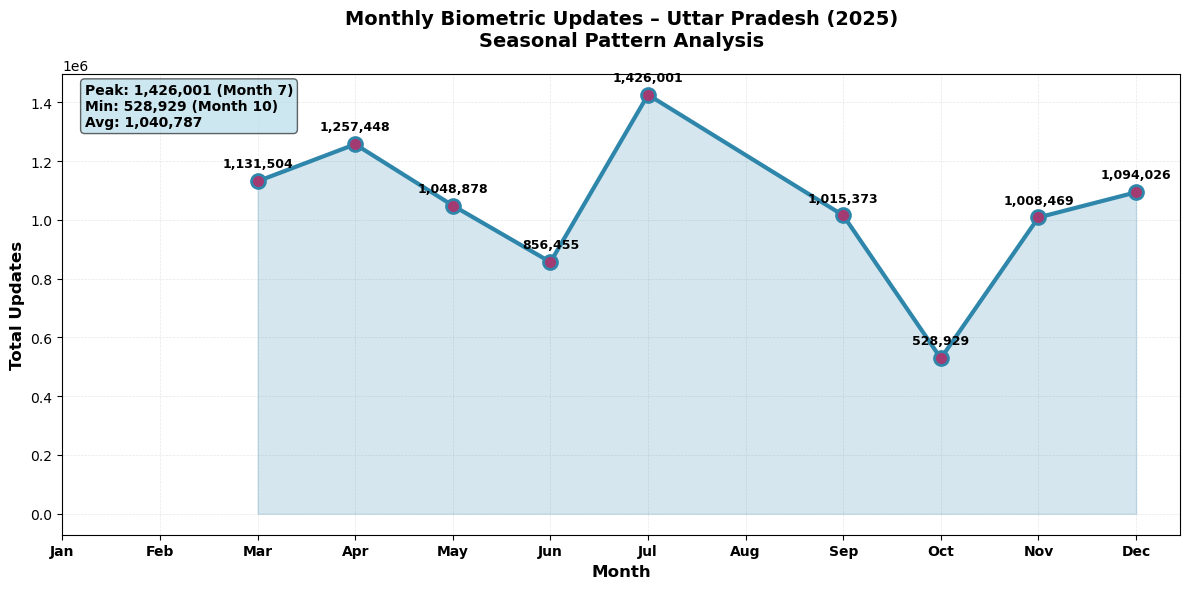

Months with data: [3, 4, 5, 6, 7, 9, 10, 11, 12]


In [30]:
# Monthly aggregation for top state
monthly_updates = (
    biometric_df[biometric_df['state'] == top_state]
    .groupby(['year', 'month'], as_index=False)['count']
    .sum()
)

if len(monthly_updates) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot line with enhanced styling
    ax.plot(monthly_updates['month'], monthly_updates['count'], 
           marker='o', linewidth=3, markersize=10, color='#2E86AB', 
           markerfacecolor='#A23B72', markeredgewidth=2, markeredgecolor='#2E86AB')
    
    # Fill under the curve
    ax.fill_between(monthly_updates['month'], monthly_updates['count'], alpha=0.2, color='#2E86AB')
    
    # Customize the plot
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, fontsize=10, fontweight='bold')
    
    ax.set_title(f"Monthly Biometric Updates – {top_state} (2025)\nSeasonal Pattern Analysis", 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Month", fontsize=12, fontweight='bold')
    ax.set_ylabel("Total Updates", fontsize=12, fontweight='bold')
    
    # Add data labels on points
    for x, y in zip(monthly_updates['month'], monthly_updates['count']):
        ax.annotate(f'{int(y):,}', xy=(x, y), xytext=(0, 10), 
                   textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
    
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Add statistics box
    stats_text = f'Peak: {monthly_updates["count"].max():,.0f} (Month {monthly_updates.loc[monthly_updates["count"].idxmax(), "month"]:.0f})\n'
    stats_text += f'Min: {monthly_updates["count"].min():,.0f} (Month {monthly_updates.loc[monthly_updates["count"].idxmin(), "month"]:.0f})\n'
    stats_text += f'Avg: {monthly_updates["count"].mean():,.0f}'
    props = dict(boxstyle='round', facecolor='lightblue', alpha=0.6)
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
           verticalalignment='top', bbox=props, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/monthly_trend_{top_state}.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Months with data: {monthly_updates['month'].tolist()}")

### Insight 3: Monthly Seasonality

Monthly biometric updates in Uttar Pradesh show clear intra-year variability, with a pronounced peak around mid-year (July) and a sharp decline in October, indicating possible seasonal or operational influences on update demand.

## State-wise Distribution

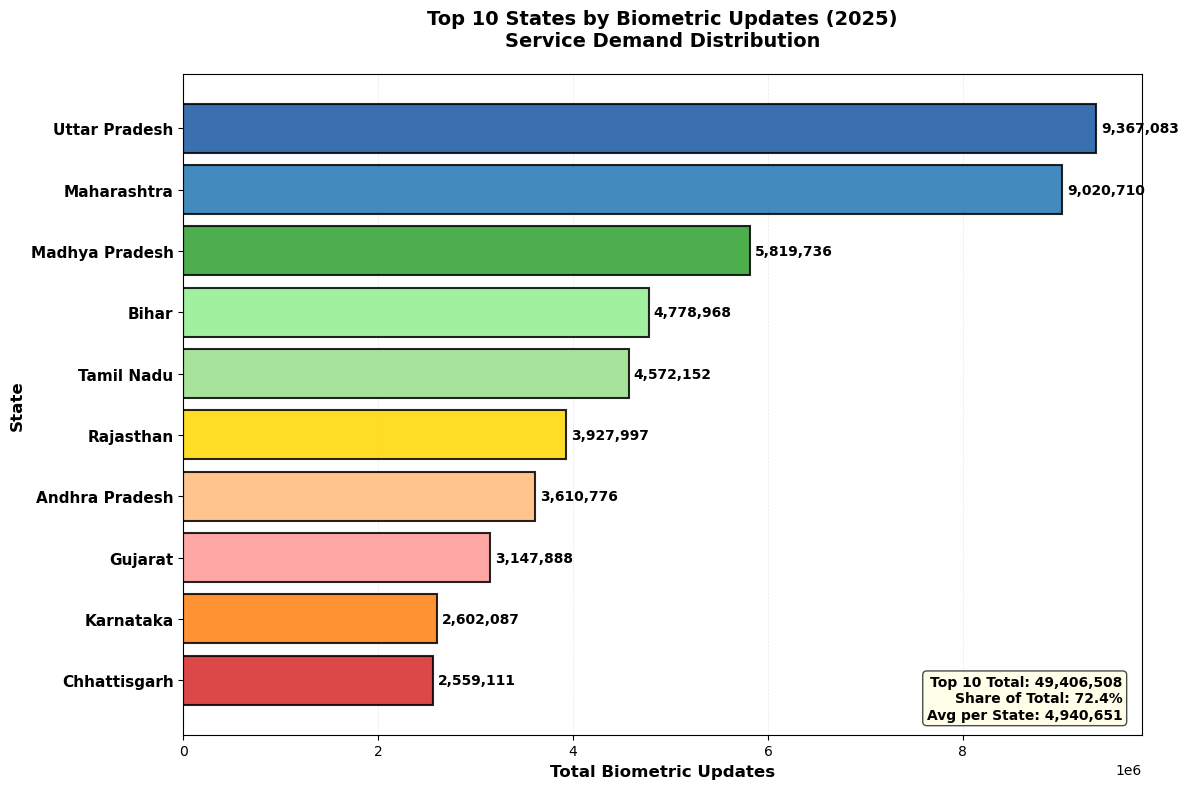


Top 10 States Analysis:
Total updates (Top 10): 49,406,508
Percentage of all updates: 72.4%


In [31]:
# Top 10 states by biometric updates
top_10_states = biometric_df.groupby('state')['count'].sum().nlargest(10).sort_values()

# Create figure with enhanced styling
fig, ax = plt.subplots(figsize=(12, 8))

# Create color gradient using a list of colors
color_list = ['#d62728', '#ff7f0e', '#ff9896', '#ffbb78', '#ffd700', 
              '#98df8a', '#90ee90', '#2ca02c', '#1f77b4', '#1756a3']

# Create horizontal bar chart
bars = ax.barh(range(len(top_10_states)), top_10_states.values, color=color_list, 
               edgecolor='black', linewidth=1.5, alpha=0.85)

# Set y-axis labels
ax.set_yticks(range(len(top_10_states)))
ax.set_yticklabels(top_10_states.index, fontsize=11, fontweight='bold')

# Add value labels on bars
for idx, (bar, value) in enumerate(zip(bars, top_10_states.values)):
    ax.text(value + 50000, idx, f'{value:,.0f}', va='center', fontsize=10, fontweight='bold')

# Customize the plot
ax.set_xlabel("Total Biometric Updates", fontsize=12, fontweight='bold')
ax.set_ylabel("State", fontsize=12, fontweight='bold')
ax.set_title("Top 10 States by Biometric Updates (2025)\nService Demand Distribution", 
            fontsize=14, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, axis='x', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Add total and percentage information
total_updates = top_10_states.sum()
all_updates = biometric_df['count'].sum()
percentage = (total_updates / all_updates) * 100

info_text = f'Top 10 Total: {total_updates:,.0f}\n'
info_text += f'Share of Total: {percentage:.1f}%\n'
info_text += f'Avg per State: {total_updates/10:,.0f}'
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.7)
ax.text(0.98, 0.02, info_text, transform=ax.transAxes, fontsize=10,
       verticalalignment='bottom', horizontalalignment='right', bbox=props, fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/figures/top_10_states_biometric.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTop 10 States Analysis:")
print(f"Total updates (Top 10): {total_updates:,.0f}")
print(f"Percentage of all updates: {percentage:.1f}%")

### Insight 4: Geographic Concentration

A small subset of large states (e.g., Uttar Pradesh, Maharashtra) accounts for a disproportionately high share of biometric updates, indicating concentration of Aadhaar service demand and the need for state-specific capacity planning.

## Key Insights Summary

### Critical Findings from EDA:

1. **Update-to-Enrolment Efficiency**: States with higher update-to-enrolment ratios may indicate higher rework, biometric ageing, or enrolment quality challenges, highlighting opportunities for process improvement.

2. **Scale-Driven Patterns**: Large states like Uttar Pradesh and Maharashtra dominate the update landscape, reflecting population-scale service demand and requiring targeted resource allocation.

3. **Monthly Seasonality**: Intra-year trends show variability with distinct peaks and troughs, suggesting seasonal factors that can inform operational planning and anomaly detection.

4. **State Heterogeneity**: Wide variance in update behaviors across states motivates state-specific analysis and anomaly detection approaches.